In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print("✔ Libraries loaded.")

✔ Libraries loaded.


In [2]:
TICKER = "AAPL"       
START  = "2020-01-01"
END    = "2024-12-31"

raw = yf.download(TICKER, start=START, end=END, auto_adjust=True)
raw.columns = raw.columns.get_level_values(0)   # flatten MultiIndex if present
raw.dropna(inplace=True)

print(f"Ticker  : {TICKER}")
print(f"Period  : {START}  →  {END}")
print(f"Shape   : {raw.shape[0]} rows × {raw.shape[1]} columns")
raw.head()

[*********************100%***********************]  1 of 1 completed

Ticker  : AAPL
Period  : 2020-01-01  →  2024-12-31
Shape   : 1257 rows × 5 columns


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
2020-01-07,71.928070,72.533110,71.708710,72.277594,108872000
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200


In [3]:
print("── Column Names ─────────────────────────────────────")
print(raw.columns.tolist())

print("\n── Data Types & Null Check ──────────────────────────")
raw.info()

print("\n── Descriptive Statistics ───────────────────────────")
raw.describe().round(2)

── Column Names ─────────────────────────────────────
['Close', 'High', 'Low', 'Open', 'Volume']

── Data Types & Null Check ──────────────────────────
<class 'pandas.DataFrame'>
DatetimeIndex: 1257 entries, 2020-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1257 non-null   float64
 1   High    1257 non-null   float64
 2   Low     1257 non-null   float64
 3   Open    1257 non-null   float64
 4   Volume  1257 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.9 KB

── Descriptive Statistics ───────────────────────────


Price,Close,High,Low,Open,Volume
count,1257.00,1257.00,1257.00,1257.00,1.257000e+03
mean,151.44,152.96,149.74,151.28,9.061168e+07
std,41.82,41.96,41.59,41.76,5.324605e+07
min,54.21,55.21,51.37,55.11,2.323470e+07
25%,126.37,127.45,124.35,125.84,5.546960e+07
50%,150.08,151.83,148.08,149.91,7.629970e+07
75%,175.91,177.61,174.48,175.76,1.077601e+08
max,257.61,258.69,256.23,256.79,4.265100e+08


In [4]:
df = raw.copy()

# Lag features: yesterday's values
df["Prev_Close"]  = df["Close"].shift(1)
df["Prev_High"]   = df["High"].shift(1)
df["Prev_Low"]    = df["Low"].shift(1)
df["Prev_Volume"] = df["Volume"].shift(1)

# Rolling averages
df["MA_5"]  = df["Close"].rolling(5).mean()
df["MA_10"] = df["Close"].rolling(10).mean()

# Daily price range
df["Daily_Range"] = df["High"] - df["Low"]

# Drop rows with NaN from shifting/rolling
df.dropna(inplace=True)

print(f"Dataset shape after feature engineering: {df.shape}")
df.head()

Dataset shape after feature engineering: (1248, 12)


Price,Close,High,Low,Open,Volume,Prev_Close,Prev_High,Prev_Low,Prev_Volume,MA_5,MA_10,Daily_Range
Date,,,,,,,,,,,,
2020-01-15,75.049675,76.052459,74.618187,75.172615,121923600,75.372719,76.551476,75.249786,161954400.0,75.254103,73.764877,1.434273
2020-01-16,75.989799,76.100690,75.230481,75.592062,108829200,75.049675,76.052459,74.618187,121923600.0,75.524565,74.123807,0.870208
2020-01-17,76.831093,76.833498,75.931959,76.238095,137816400,75.989799,76.100690,75.230481,108829200.0,75.929539,74.637254,0.901539
2020-01-21,76.310417,76.900995,76.173015,76.459869,110843200,76.831093,76.833498,75.931959,137816400.0,75.910741,75.041501,0.727980
2020-01-22,76.582802,77.134810,76.488787,76.794923,101832400,76.310417,76.900995,76.173015,110843200.0,76.152757,75.506974,0.646022


In [5]:
FEATURES = ["Open", "High", "Low", "Volume",
            "Prev_Close", "Prev_High", "Prev_Low",
            "Prev_Volume", "MA_5", "MA_10", "Daily_Range"]

TARGET = "Close"

X = df[FEATURES]
y = df[TARGET]

print(f"Features : {FEATURES}")
print(f"Target   : {TARGET}")
print(f"X shape  : {X.shape}")
print(f"y shape  : {y.shape}")

Features : ['Open', 'High', 'Low', 'Volume', 'Prev_Close', 'Prev_High', 'Prev_Low', 'Prev_Volume', 'MA_5', 'MA_10', 'Daily_Range']
Target   : Close
X shape  : (1248, 11)
y shape  : (1248,)


In [6]:
# Time-series split — no shuffling to preserve chronological order
SPLIT = 0.80
split_idx = int(len(X) * SPLIT)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Train period     : {X_train.index[0].date()}  →  {X_train.index[-1].date()}")
print(f"Test  period     : {X_test.index[0].date()}   →  {X_test.index[-1].date()}")

Training samples : 998
Testing  samples : 250
Train period     : 2020-01-15  →  2024-01-02
Test  period     : 2024-01-03   →  2024-12-30


In [7]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("── Linear Regression Results ────────────────────────")
print(f"  MAE  : {mean_absolute_error(y_test, lr_preds):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, lr_preds)):.4f}")
print(f"  R²   : {r2_score(y_test, lr_preds):.4f}")

── Linear Regression Results ────────────────────────
  MAE  : 0.8256
  RMSE : 1.1028
  R²   : 0.9981


In [8]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("── Random Forest Results ────────────────────────────")
print(f"  MAE  : {mean_absolute_error(y_test, rf_preds):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, rf_preds)):.4f}")
print(f"  R²   : {r2_score(y_test, rf_preds):.4f}")

── Random Forest Results ────────────────────────────
  MAE  : 17.8735
  RMSE : 24.8623
  R²   : 0.0450


In [9]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE":   [mean_absolute_error(y_test, lr_preds),
              mean_absolute_error(y_test, rf_preds)],
    "RMSE":  [np.sqrt(mean_squared_error(y_test, lr_preds)),
              np.sqrt(mean_squared_error(y_test, rf_preds))],
    "R²":    [r2_score(y_test, lr_preds),
              r2_score(y_test, rf_preds)]
}).round(4)

print("── Model Comparison ─────────────────────────────────")
results

── Model Comparison ─────────────────────────────────


,Model,MAE,RMSE,R²
0,Linear Regression,0.8256,1.1028,0.9981
1,Random Forest,17.8735,24.8623,0.0450


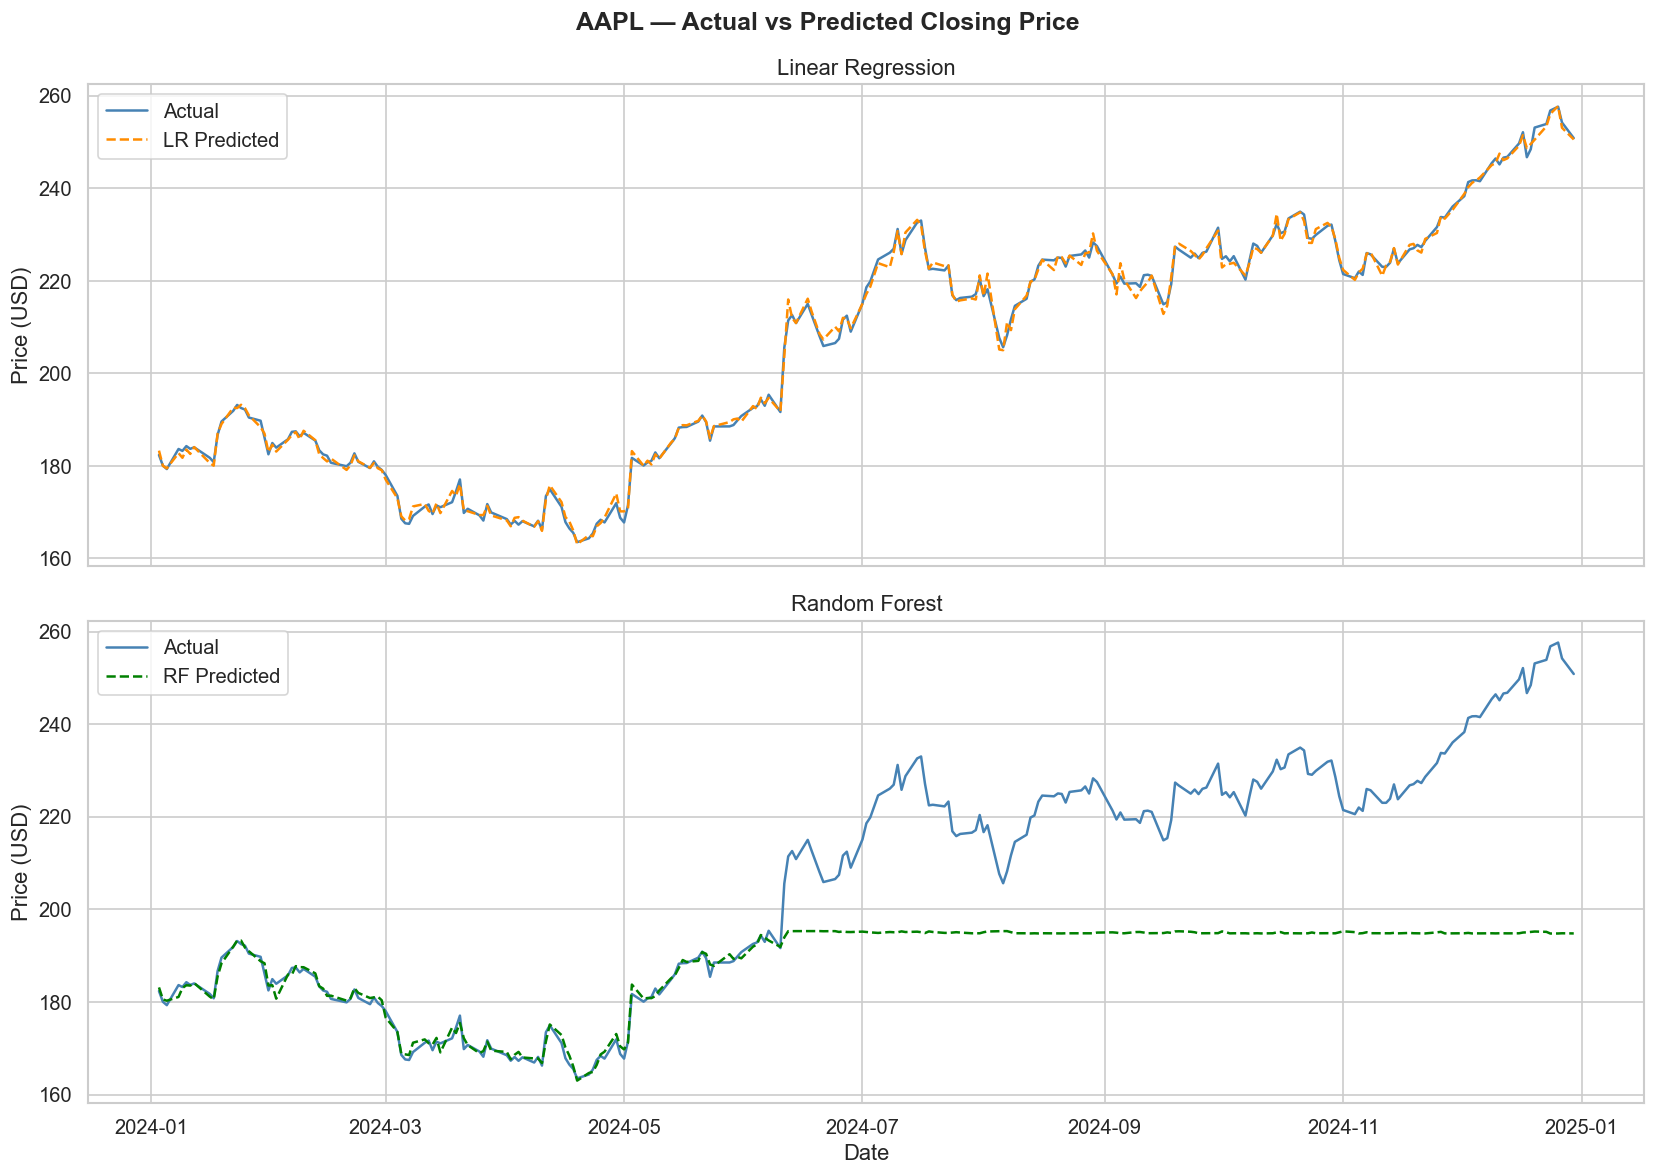

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f"{TICKER} — Actual vs Predicted Closing Price",
             fontsize=15, fontweight="bold")

test_index = X_test.index

# ── Linear Regression ──
axes[0].plot(test_index, y_test.values,  color="steelblue",  linewidth=1.5, label="Actual")
axes[0].plot(test_index, lr_preds,       color="darkorange", linewidth=1.5, linestyle="--", label="LR Predicted")
axes[0].set_title("Linear Regression")
axes[0].set_ylabel("Price (USD)")
axes[0].legend()

# ── Random Forest ──
axes[1].plot(test_index, y_test.values, color="steelblue",  linewidth=1.5, label="Actual")
axes[1].plot(test_index, rf_preds,      color="green",      linewidth=1.5, linestyle="--", label="RF Predicted")
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Price (USD)")
axes[1].legend()

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", bbox_inches="tight")
plt.show()

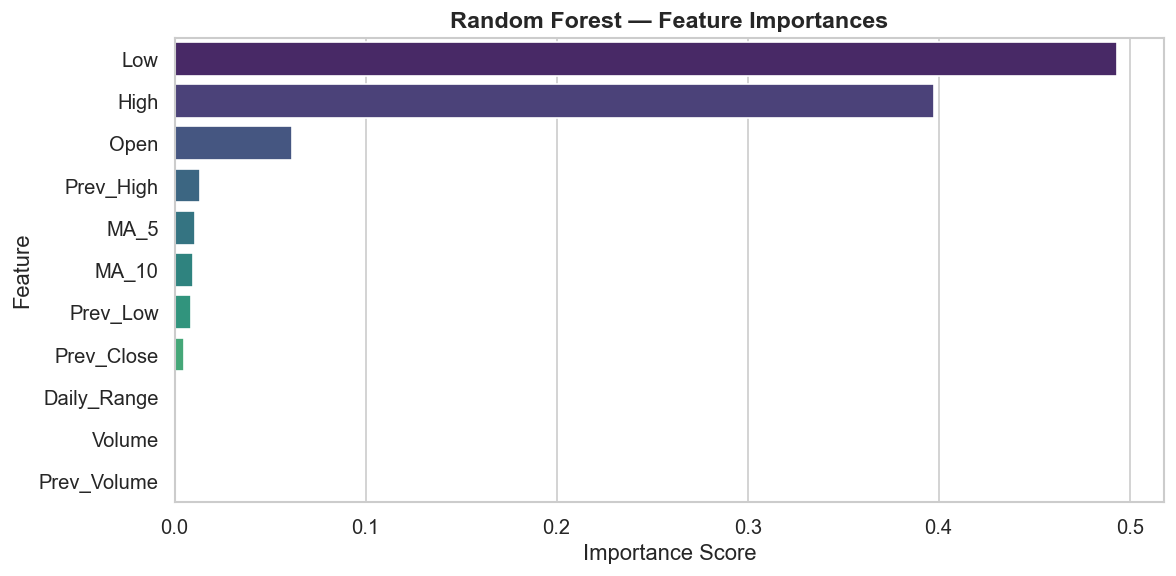

In [11]:
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis", ax=ax)
ax.set_title("Random Forest — Feature Importances", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches="tight")
plt.show()

In [12]:
last_row = X.iloc[[-1]]   # most recent available row

lr_next = lr_model.predict(last_row)[0]
rf_next = rf_model.predict(last_row)[0]
last_actual = y.iloc[-1]

print("── Next-Day Closing Price Forecast ─────────────────")
print(f"  Last known Close      : ${last_actual:.2f}")
print(f"  Linear Regression     : ${lr_next:.2f}")
print(f"  Random Forest         : ${rf_next:.2f}")

── Next-Day Closing Price Forecast ─────────────────
  Last known Close      : $250.83
  Linear Regression     : $250.55
  Random Forest         : $194.80
